In [26]:
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/HOGs_NN")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import cv2
import numpy as np
import torch
import google.colab.patches as colab_pathes
import matplotlib.pyplot as plt
from MNIST import MNIST

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler

In [28]:
class HOGsDataset(Dataset):
  def __init__(self,image_file,label_file):
    self.hogs_database = MNIST(image_file,label_file)

    winSize = (28,28)
    blockSize = (28,28)
    blockStride = (1,1)
    cellSize = (14,14)
    nbins = 9

    self.HOG = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)
  def __len__(self):
    return len(self.hogs_database)
  def __getitem__(self, index):
    image, label = self.hogs_database.getitem(index)
    a_hog = self.HOG.compute(image)
    a_hog = a_hog.reshape((-1))
    a_hog = a_hog.astype(np.float32)

    a_hog = torch.tensor(a_hog)
    label = torch.tensor(label, dtype=torch.long)
    return a_hog,label

In [29]:
class NNModel(torch.nn.Module):
  def __init__(self):
    super(NNModel, self).__init__()
    self.fc_1 = torch.nn.Linear(36, 20, bias=True)
    self.fc_2 = torch.nn.Linear(20, 10, bias=True)
  def forward(self, x):
    x = torch.nn.functional.relu(self.fc_1(x))
    y = self.fc_2(x)
    return y

In [30]:
n_epoch = 50
batch_size = 20
eta = 0.01

In [31]:
minst_train = HOGsDataset("train-images.idx3-ubyte","train-labels.idx1-ubyte")

In [32]:
index_list = list(range(len(minst_train)))
sample = SubsetRandomSampler(index_list)
loader = DataLoader(dataset=minst_train, sampler=sample, batch_size=batch_size)

In [33]:
nn_model = NNModel()
optimizer = torch.optim.SGD(nn_model.parameters(), eta)
criterion = torch.nn.CrossEntropyLoss()

In [34]:
is_GPU = torch.cuda.is_available()
if is_GPU:
  nn_model.cuda()

In [ ]:
loss_list = []
for epoch in range(n_epoch):
  total_loss = 0
  n_batch = 0

  for hogs, target_labels in loader:
    if is_GPU:
      hogs = hogs.cuda()
    pred_labels = nn_model(hogs)
    if is_GPU:
      target_labels = target_labels.cuda()
    loss = criterion(pred_labels, target_labels)
    total_loss += loss.item()
    n_batch += 1
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  average_loss = total_loss / n_batch
  loss_list.append(average_loss)
  print(f"{epoch}:{average_loss}")

In [36]:
torch.save(nn_model.state_dict(), 'nn.pth')

[2.2444696744680406, 1.9498204938173294, 1.658676750500997, 1.390101490775744, 1.1679241163134575, 1.004712779422601, 0.8903252754112084, 0.8088221798737844, 0.748842762062947, 0.7019756737003724, 0.6638462413549423, 0.6312826928098997, 0.6030330131252607, 0.5779120984772841, 0.5554904118428627, 0.5350631584947307, 0.5165451354334751, 0.49983003495633604, 0.4847892716800173, 0.47117570747683446, 0.45886115565647684, 0.44768015828977026, 0.437460732926925, 0.4287054822271069, 0.4207974262560407, 0.4134945301115513, 0.40651706894487144, 0.40058644873897237, 0.3947745198942721, 0.3898618234495322, 0.38506811242053907, 0.3806704721252124, 0.3767484505499403, 0.37297983101010324, 0.36930381376172106, 0.3662671534505983, 0.36281515172868967, 0.36006596305842203, 0.3574903601668775, 0.3550649739888807, 0.35259795436883967, 0.3501748381952445, 0.3480357062295079, 0.3461647034312288, 0.3440642036559681, 0.34254469524448117, 0.3405560074249903, 0.33925189496825137, 0.33766719842329623, 0.3359396

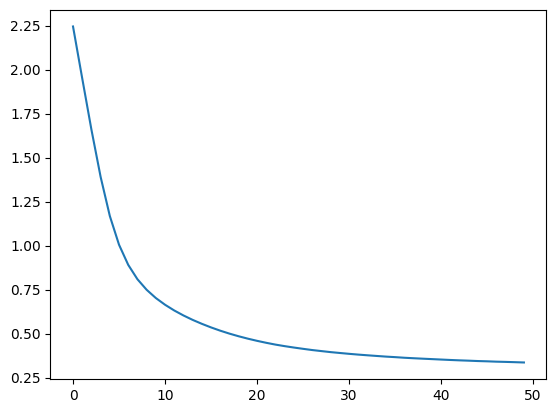

In [37]:
print(f"{loss_list}")
plt.plot(range(len(loss_list)),loss_list)

In [38]:
mnist_test = HOGsDataset("t10k-images.idx3-ubyte", "t10k-labels.idx1-ubyte")

In [42]:
n_test = len(mnist_test)
n_correct = 0
n_wrong = 0
for index in range(n_test):
  hog, target_label = mnist_test[index]
  hog = torch.unsqueeze(hog, dim=0)
  if is_GPU:
    hog = hog.cuda()
  pred_label = nn_model(hog)
  pred_label = torch.squeeze(pred_label)
  pred_label = torch.argmax(pred_label)
  if target_label == pred_label:
    n_correct += 1
  else:
    n_wrong += 1

In [43]:
accuracy = n_correct / n_test
print(f'{n_correct}')
print(f'accuracy:{accuracy*100.}%')

9025
accuracy:90.25%
